<a href="https://colab.research.google.com/github/Arce369/Machine-Learning/blob/main/Supervised%20learning/Public_transport/Public_transport_delays_wwe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Public Transit Delays with weather & Traffic Data

This dataset was synthetically generated and may not refelct real-world data. The dataset shows how public transport delays according to multiple real-world factors such as: Transport Timetables, Weather Conditions, City Events, Traffic Congestion, Contextual Features.

---
## Objectives:


The main challenge of this notebook is to predict whether a trip will be delayed or not using all the features described. This is framed as a **binary classification problem**, where the target variable indicates:

- **0** -> the trip was not delayed  
- **1** -> the trip experienced a delay  

While the primary focus is classification, the notebook will also explore a secondary task: **estimating the number of minutes a trip will be delayed**. This transforms the problem into a **regression task**, allowing us to quantify the delay rather than simply detecting its presence.

By addressing both tasks, the project aims to build a comprehensive predictive pipeline capable of:

- Identifying trips at risk of delay  
- Providing an approximate delay duration for operational decision-making  

## Libraries & Data

In [1]:
# standard
from typing import Sequence
import time

# machine learning core
from sklearn.linear_model import SGDClassifier, SGDRegressor, LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
import sklearn as skl
import xgboost as xgb
import statsmodels.formula.api as smf
from scipy import stats

# data manipulation
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# kaggle API
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = 'public_transport_delays.csv'

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "khushikyad001/public-transport-delays-with-weather-and-events",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df['date'] = pd.to_datetime(df['date'])
df['event_type'] = df['event_type'].fillna('No event')

pd.set_option('display.max_columns', None)
display("First 5 records:", df.head())

/tmp/ipykernel_1081/3354884350.py:30: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 261k/261k [00:00<00:00, 57.1MB/s]


'First 5 records:'

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,3,Storm,5.1,52,46,13.0,No event,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,9,Rain,34.0,64,11,11.4,No event,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,0,Clear,29.5,35,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,10,Clear,27.4,55,41,6.4,No event,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,14,Snow,0.1,90,30,18.5,No event,500,46,0,0,6,Spring,1


## EDA

In this section, we will explore the dataset to identify missing values, understand the distribution of each feature, and detect patterns that may guide the selection of an appropriate model and evaluation metric.

Because the dataset is fully simulated, the date column does not represent a real chronological timeline. For example, trips occurring on the same calendar day may belong to different seasons of the year, which means that the date itself does not encode temporal progression. Therefore, splitting the dataset strictly by chronological order would not prevent data leakage.

Instead, we will split the dataset into train and test sets based on the day of the week (weekday). This approach ensures that the model is evaluated on different operational conditions (Monday vs. Sunday, etc.) without relying on artificial temporal sequences. Any other splitting strategy pretending to follow real-world time would effectively be “cheating,” since the simulated data does not follow real temporal rules.

Later in the notebook, the **train_size** will be treated as a **hyperparameter**, allowing us to test different proportions of training data and determine which configuration yields the best model performance and generalization.

Since the dataset includes variables related to weather conditions and traffic‑related events, we will also examine how these factors influence the target variable.

In [2]:
print('Dataset shape: ', df.shape)
print('='*20)
print(df.info())
print('='*20)
print(df.describe().T)
print('='*20)
print('NA values')
print(df.isnull().sum())
print('='*20)
print('Dates: ',(df.date.unique()))

Dataset shape:  (2000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trip_id                     2000 non-null   object        
 1   date                        2000 non-null   datetime64[ns]
 2   time                        2000 non-null   object        
 3   transport_type              2000 non-null   object        
 4   route_id                    2000 non-null   object        
 5   origin_station              2000 non-null   object        
 6   destination_station         2000 non-null   object        
 7   scheduled_departure         2000 non-null   object        
 8   scheduled_arrival           2000 non-null   object        
 9   actual_departure_delay_min  2000 non-null   int64         
 10  actual_arrival_delay_min    2000 non-null   int64         
 11  weather_condition           2

In [3]:
cat_cols = df.select_dtypes(
    include=['object','string','category']
).columns


num_cols = df.select_dtypes(
    include=['int64','float64']
).columns

print('\nCategorical columns:')
print(cat_cols)
print('\nNumerical columns:')
print(num_cols)


Categorical columns:
Index(['trip_id', 'time', 'transport_type', 'route_id', 'origin_station',
       'destination_station', 'scheduled_departure', 'scheduled_arrival',
       'weather_condition', 'event_type', 'season'],
      dtype='object')

Numerical columns:
Index(['actual_departure_delay_min', 'actual_arrival_delay_min',
       'temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'delayed'],
      dtype='object')


In [4]:
df['event_type'].value_counts(dropna=False)

,count
event_type,
No event,1173
Festival,221
Sports,212
Concert,203
Parade,105
Protest,86


In [5]:
size_train = 0.7
# Clasificcation task
X_train_class = df.iloc[:int(2000*size_train),:].drop(columns='delayed',axis=1)
y_train_class = df.iloc[:int(2000*size_train),-1]
X_test_class = df.iloc[int(2000*size_train):,:].drop(columns='delayed',axis=1)
y_test_class = df.iloc[int(2000*size_train):,-1]

# Regression task
X_train_reg = df.iloc[:int(2000*size_train),:].drop(columns='actual_arrival_delay_min',axis=1)
y_train_reg = df.loc[:int(2000*size_train),'actual_arrival_delay_min']
X_test_reg = df.iloc[int(2000*size_train):,:].drop(columns='actual_arrival_delay_min',axis=1)
y_test_reg = df.loc[int(2000*size_train):,'actual_arrival_delay_min']

print('X_train shape: ', X_train_class.shape)
print('y_train shape: ', y_train_class.shape)
print('X_test shape: ', X_test_class.shape)
print('y_test shape: ', y_test_class.shape)

X_train shape:  (1400, 23)
y_train shape:  (1400,)
X_test shape:  (600, 23)
y_test shape:  (600,)


In [6]:
display(y_train_class.value_counts(normalize=True))

,proportion
delayed,
1,0.747857
0,0.252143


In [7]:
def eda_visualization(X_train, y_train, task="classification"):
    """
    EDA.

    Parameters
    ----------
    X_train : DataFrame de features
    y_train : Series del target
        - task="classification" -> y_train = 'delayed' (binario)
        - task="regression"     -> y_train = 'actual_arrival_delay_min' (continuo)
    task : str, "classification" o "regression"
    """
    assert task in ("classification", "regression"), "task must be 'classification' or 'regression'"

    target_name = y_train.name if y_train.name else "target"
    eda_df = pd.concat([X_train, y_train.rename(target_name)], axis=1)

    ylabel = "Delay Rate (proportion)" if task == "classification" else "Average Delay (Minutes)"

    def barplot_by_group(col, title, xlabel):
        agg = eda_df.groupby(col)[target_name].mean().sort_values()
        fig, ax = plt.subplots(figsize=(10, 5))
        agg.plot(kind="bar", ax=ax, color='orange' if task == 'classification' else 'steelblue')
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=45)
        fig.tight_layout()
        plt.show()
        plt.close(fig)

    # ----------------------------
    # Distribución del target
    # ----------------------------
    fig, ax = plt.subplots(figsize=(6, 4))
    if task == "classification":
        eda_df[target_name].value_counts(normalize=True).plot(
            kind="bar", ax=ax, color=["seagreen", "indianred"]
        )
        ax.set_title("Class Balance")
        ax.set_ylabel("Proportion")
        ax.tick_params(axis="x", rotation=0)
    else:
        sns.histplot(eda_df[target_name], kde=True, ax=ax, color="steelblue")
        ax.set_title("Distribution of Arrival Delay (min)")
        ax.set_xlabel("Delay (Minutes)")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # ----------------------------
    # Weather vs Target
    # ----------------------------
    barplot_by_group(
        "weather_condition",
        f"{'Delay Rate' if task=='classification' else 'Average Delay'} by Weather Condition",
        "Weather Condition",
    )

    # ----------------------------
    # Event vs Target
    # ----------------------------
    barplot_by_group(
        "event_type",
        f"{'Delay Rate' if task=='classification' else 'Average Delay'} by Event Type",
        "Event Type",
    )

    # ----------------------------
    # Target by Hour
    # ----------------------------
    eda_df["hour"] = pd.to_datetime(eda_df["time"], format="%H:%M:%S", errors="coerce").dt.hour
    hour_agg = eda_df.groupby("hour")[target_name].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    hour_agg.plot(ax=ax, marker="o")
    ax.set_title(f"{'Delay Rate' if task=='classification' else 'Average Delay'} by Hour")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # ----------------------------
    # Temperature vs Target
    # ----------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    if task == "classification":
        sns.boxplot(data=eda_df, x=target_name, y="temperature_C", ax=ax)
        ax.set_title("Temperature Distribution by Delayed Class")
        ax.set_xlabel("Delayed")
    else:
        ax.scatter(eda_df["temperature_C"], eda_df[target_name], alpha=0.4)
        ax.set_title("Temperature vs Delay")
        ax.set_xlabel("Temperature (C)")
        ax.set_ylabel("Delay (Minutes)")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # ----------------------------
    # Traffic vs Target
    # ----------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    if task == "classification":
        sns.boxplot(data=eda_df, x=target_name, y="traffic_congestion_index", ax=ax)
        ax.set_title("Traffic Congestion by Delayed Class")
        ax.set_xlabel("Delayed")
    else:
        ax.scatter(eda_df["traffic_congestion_index"], eda_df[target_name], alpha=0.4)
        ax.set_title("Traffic Congestion vs Delay")
        ax.set_xlabel("Traffic Congestion Index")
        ax.set_ylabel("Delay (Minutes)")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    # ----------------------------
    # Correlation Heatmap
    # ----------------------------
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(
        eda_df.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="Spectral" if task == 'classification' else 'coolwarm',
        ax=ax,
    )
    ax.set_title("Correlation Heatmap")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

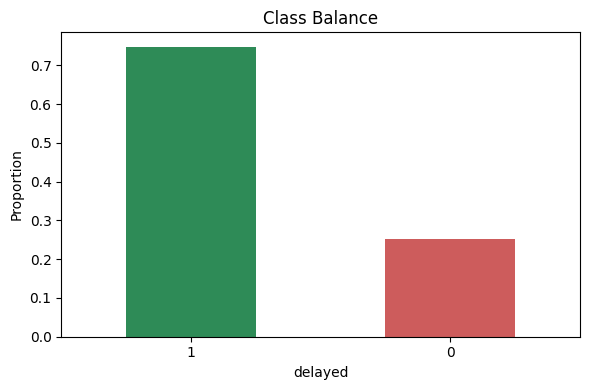

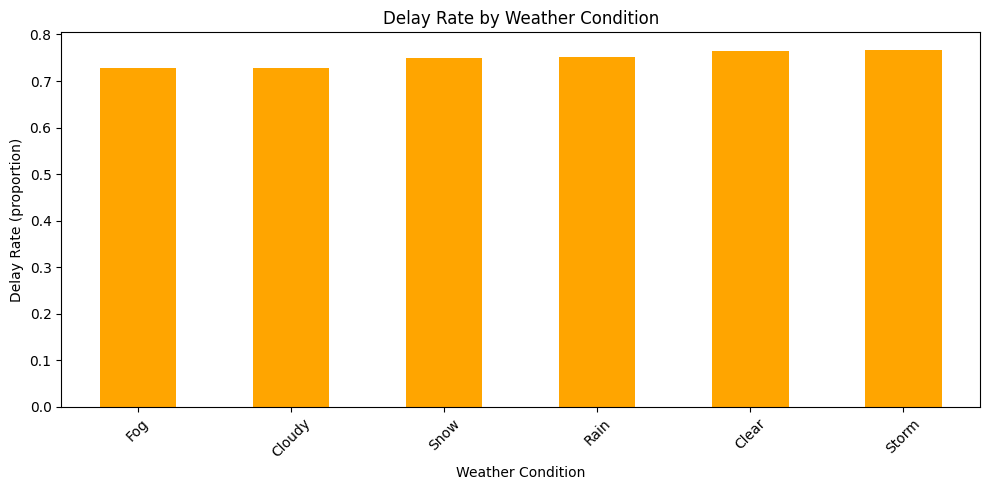

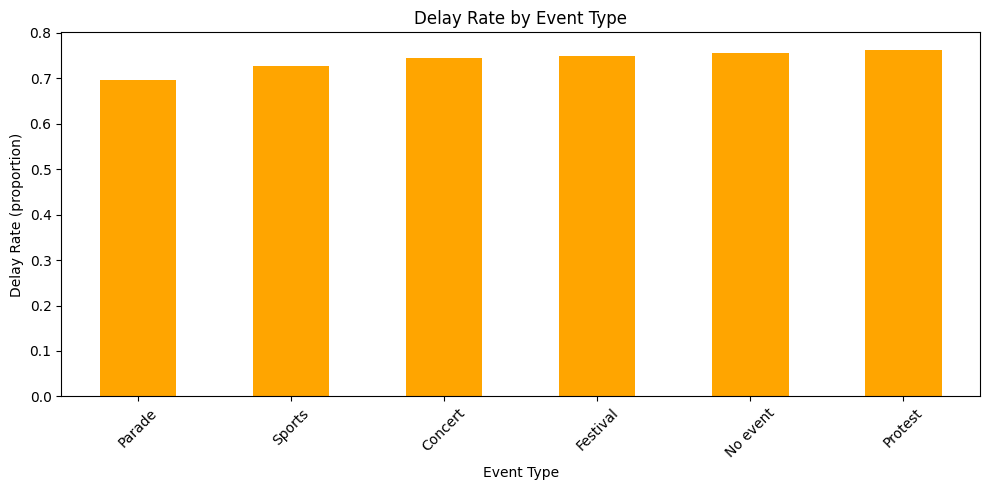

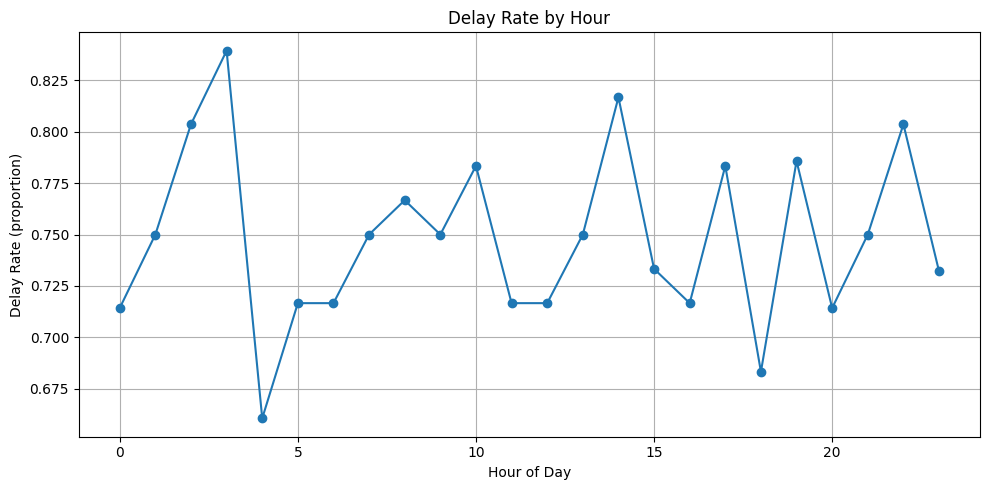

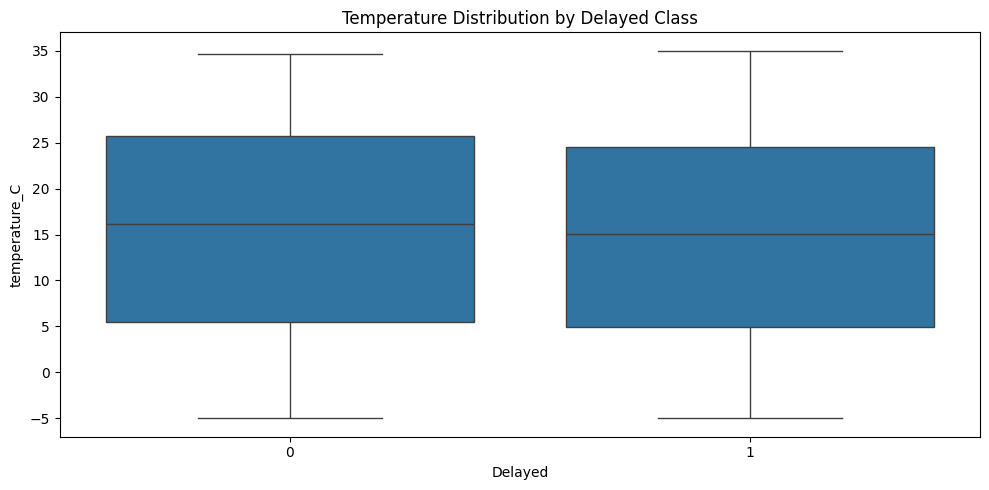

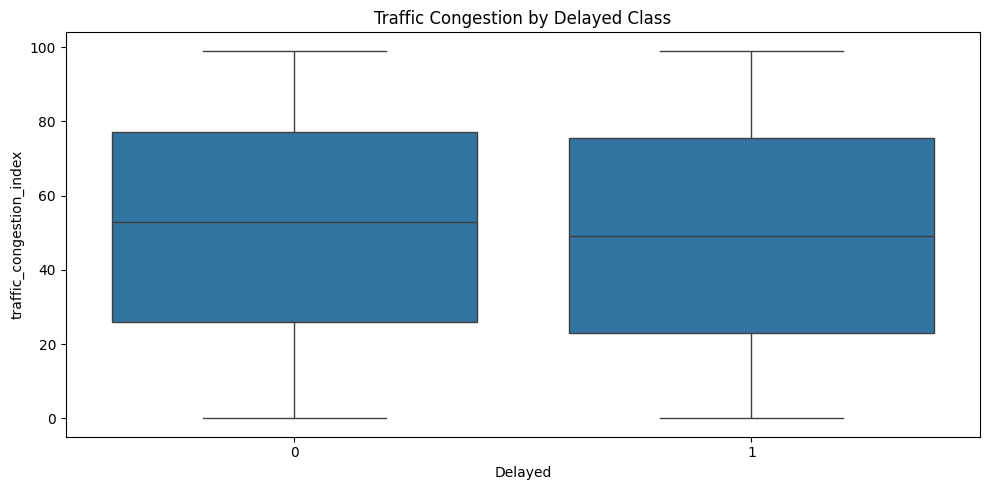

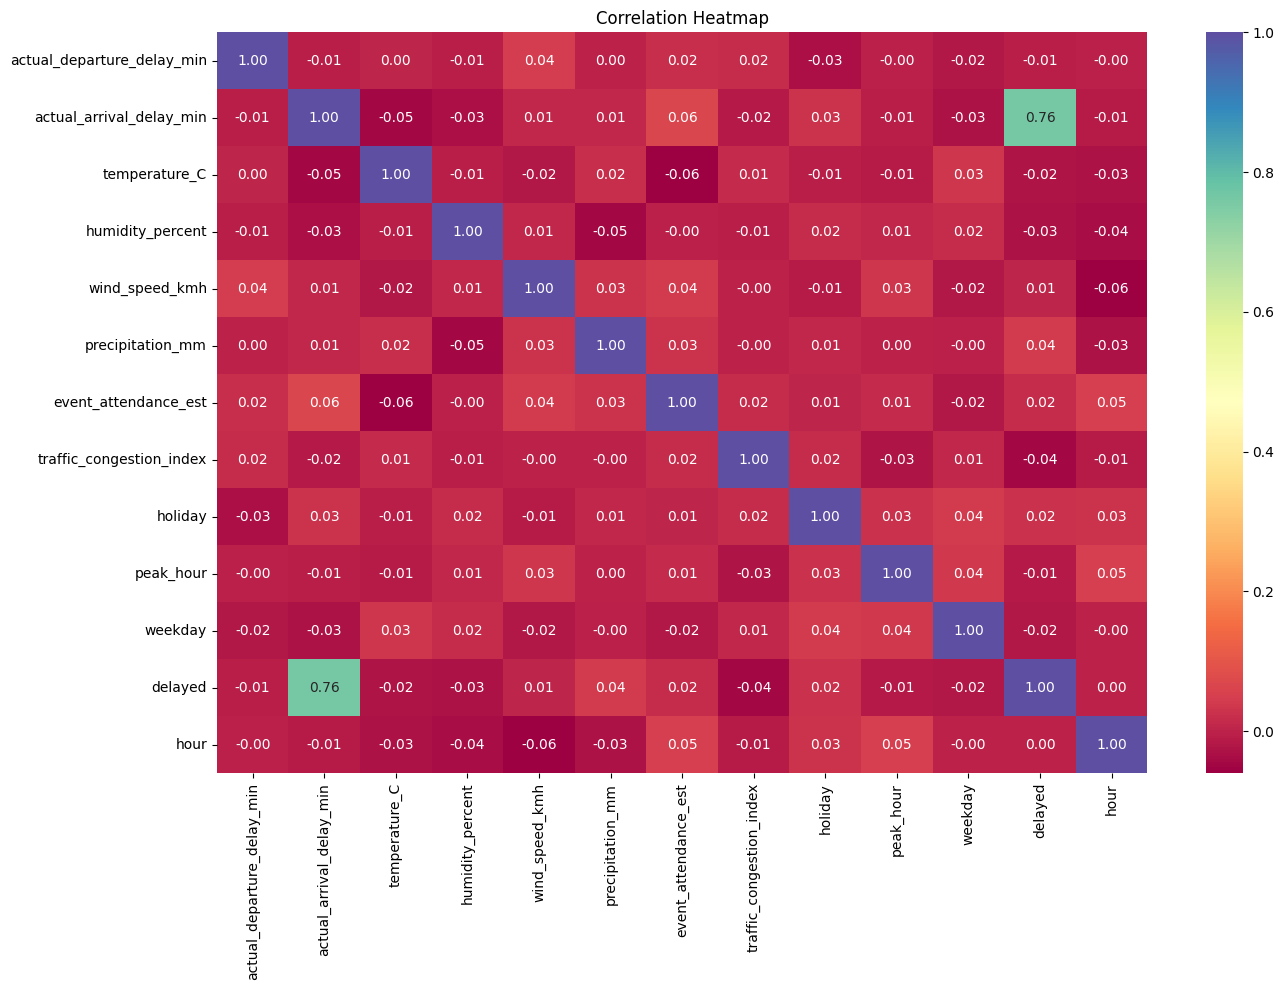

In [8]:
eda_visualization(X_train_class,y_train_class,task='classification')

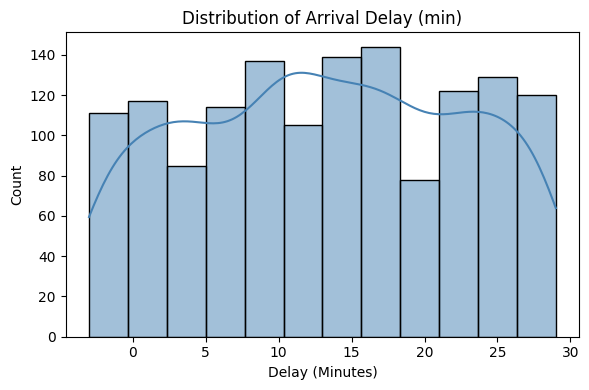

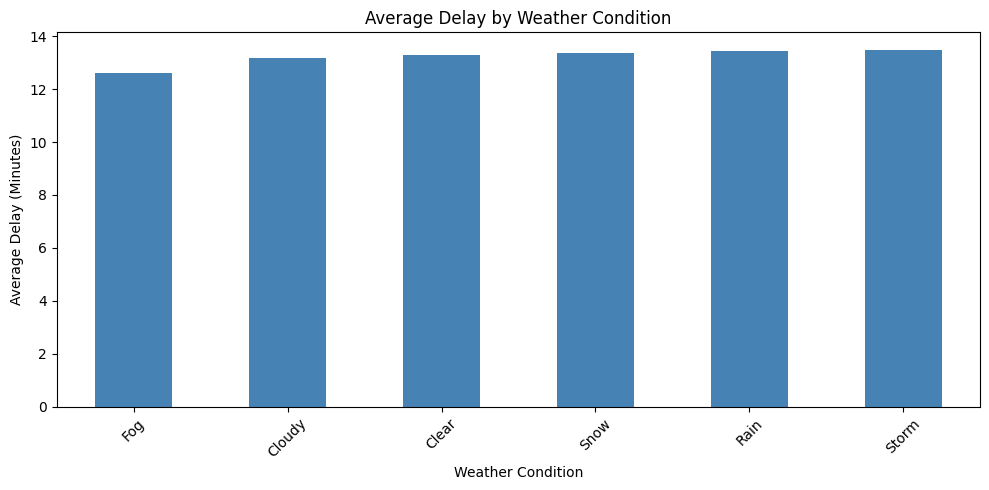

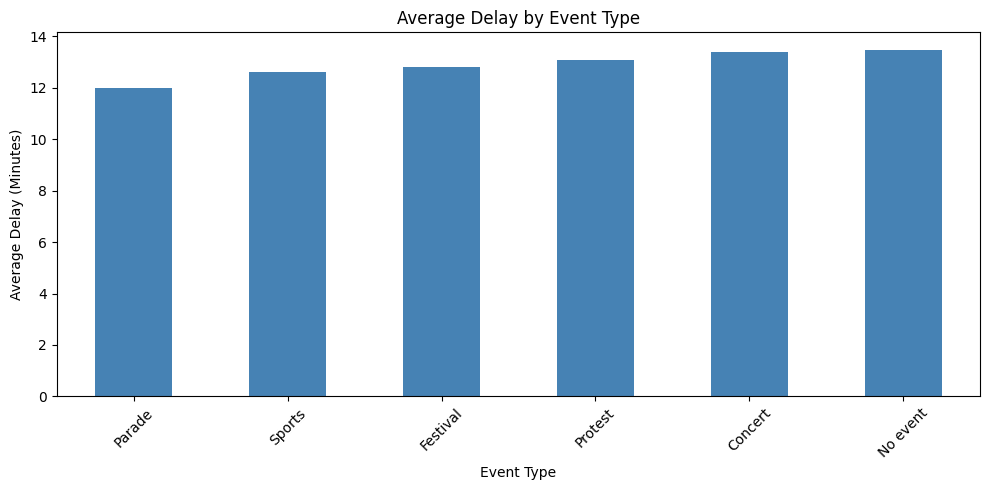

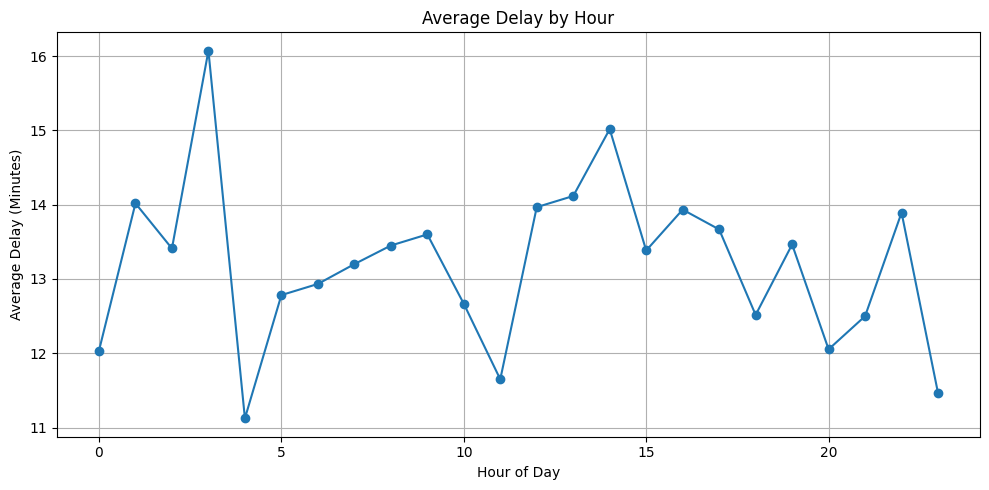

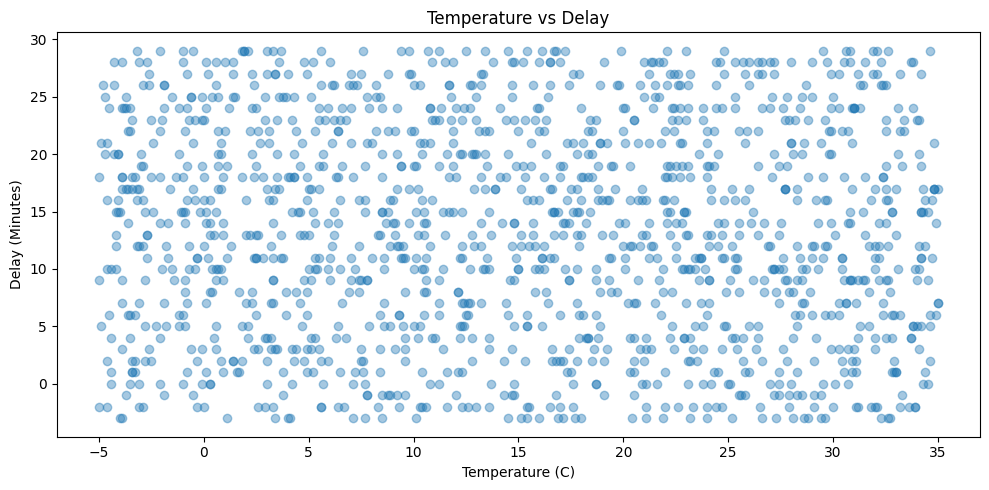

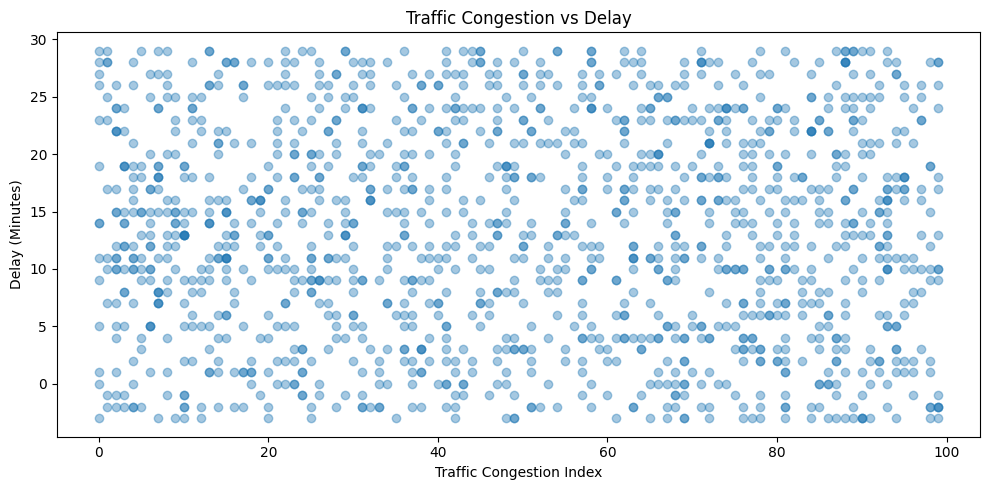

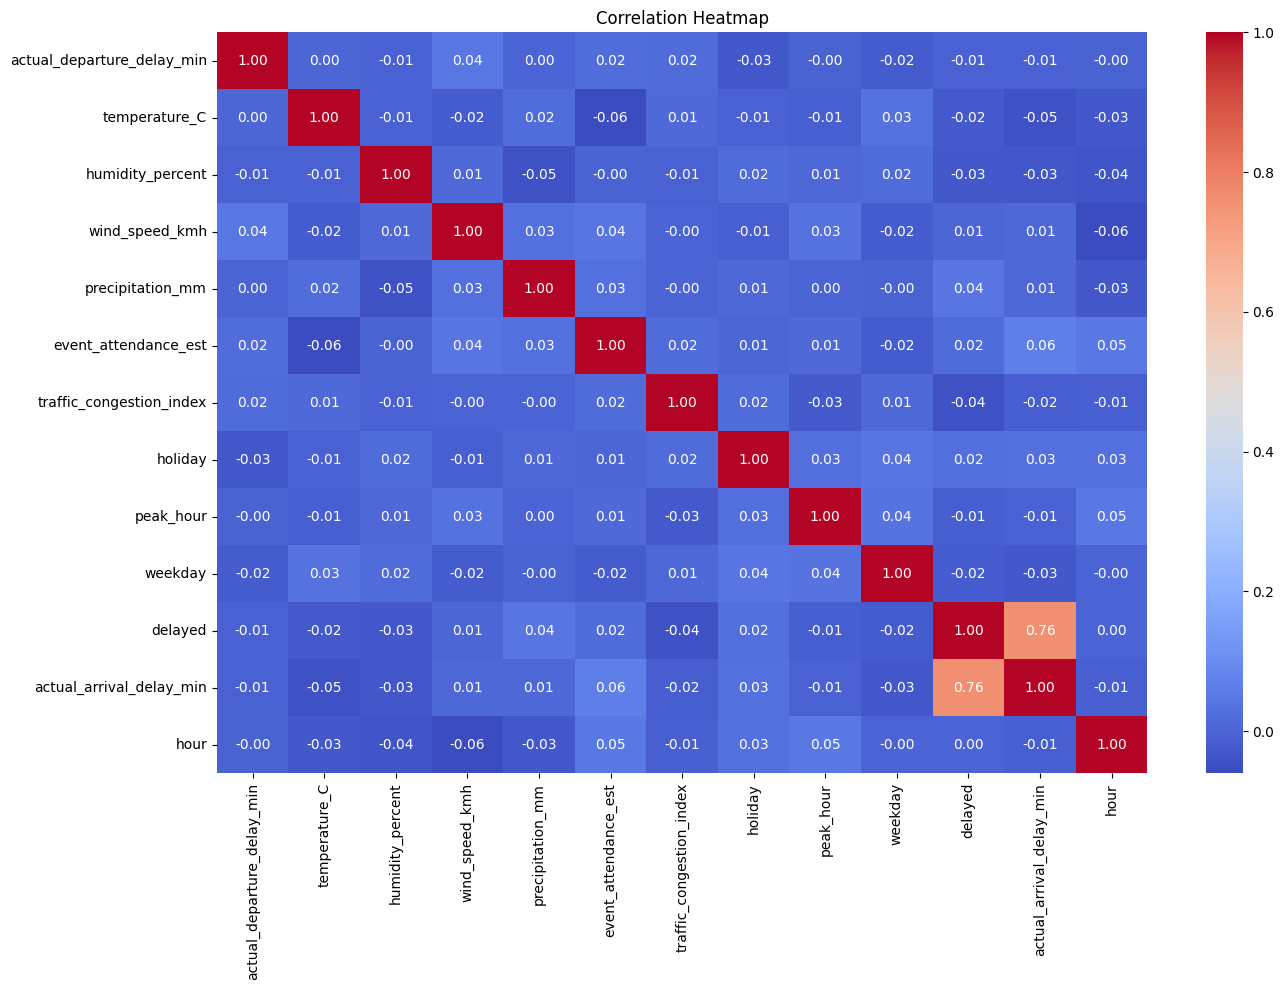

In [9]:
eda_visualization(X_train_reg,y_train_reg,task='regression')

## Preprocessing & FE

### - **Preprocess()**

This function performs all preprocessing steps required for modeling. Time variables are transformed into numerical features, and the day of the week is validated to ensure correct categorical representation. The ``task`` argument enforces the removal of target-specific columns for classification or regression. For ensemble models, the ``day`` variable is removed because weekday information is already encoded numerically. Categorical variables are encoded using label encoding for ensemble models or one-hot encoding followed by TruncatedSVD for linear models. This produces a compact and consistent feature set suitable for both tasks.

In [10]:
def preprocess(data, task="classification", ensamble=False, delayed_known = False):
    """
    Full preprocessing pipeline:
    - Time feature engineering
    - Column cleanup based on task
    - Categorical encoding (LabelEncoder or OneHot + SVD)
    """

    assert task in ("classification","regression"), \
        "task must be either 'classification' or 'regression'"

    # --- Time variables ---
    data['date'] = pd.to_datetime(data['date'])
    data['year'] = data['date'].dt.year
    data['month'] = data['date'].dt.month
    data['day'] = data['date'].dt.day
    data['hour'] = pd.to_datetime(data['time'], format='%H:%M:%S', errors='coerce').dt.hour

    # data['scheduled_arrival_min'] = pd.to_timedelta(data['scheduled_arrival']).dt.total_seconds() / 60
    # data['scheduled_departure_min'] = pd.to_timedelta(data['scheduled_departure']).dt.total_seconds() / 60

    # diff_min = (
    #     pd.to_timedelta(data['scheduled_arrival']) -
    #     pd.to_timedelta(data['scheduled_departure'])
    # ).dt.total_seconds() / 60

    # data['trip_duration_min'] = np.where(diff_min<0, diff_min + 1440, diff_min)

    # data['scheduled_arrival_min'] = data['scheduled_arrival_min'].astype(int)
    # data['scheduled_departure_min'] = data['scheduled_departure_min'].astype(int)
    # data['trip_duration_min'] = data['trip_duration_min'].astype(int)

    # Drop raw time/date columns
    data = data.drop(columns=['trip_id','date'] )
                    #  ,'time','scheduled_arrival','scheduled_departure'])

    # --- Drop columns based on task ---
    if task == "classification":
        data = data.drop(columns=['actual_arrival_delay_min','actual_departure_delay_min'])
    else:  # regression
        drop_cols_reg = ['actual_departure_delay_min']
        if not delayed_known: drop_cols_reg.append('delayed')
        data = data.drop(columns=drop_cols_reg, axis=1)

    # Identify categorical columns
    cat_cols = data.select_dtypes(include=['object','string','category']).columns

    # --- Encoding ---
    if ensamble:

        # Remove 'day' because weekday info is already numeric
        # if 'day' in data.columns:
        #     data = data.drop(columns=['day'])
        #     cat_cols = cat_cols.drop('day')

        le = skl.preprocessing.LabelEncoder()
        data[cat_cols] = data[cat_cols].apply(lambda col: le.fit_transform(col))

    else:
        # if 'weekday' in data.columns:
        #     data = data.drop(columns=['weekday'])

        data_dummies = pd.get_dummies(data[cat_cols], drop_first=True).astype(int)

        svd = skl.decomposition.TruncatedSVD(n_components=50, random_state=42)
        data_svd = svd.fit_transform(data_dummies)

        data_svd = pd.DataFrame(
            data_svd,
            columns=[f"svd_comp_{i}" for i in range(1, 51)],
            index=data.index
        )

        data = pd.concat([data.drop(columns=cat_cols), data_svd], axis=1)

    return data

def split_normalize_data(data,train_size=0.7,task='classification',seed=369,
                         scale = True):

    assert task in ("classification","regression"), \
        "task must be either 'classification' or 'regression'"

    target_col = 'delayed' if task=='classification' else 'actual_arrival_delay_min'
    X = data.drop(columns=target_col,axis=1)
    y = data[target_col]

    X_train, X_test, y_train, y_test = skl.model_selection.train_test_split(
        X, y, train_size=train_size, random_state=seed,
        stratify=y if task=='classification' else None
    )
    if scale:
        num_cols = X_train.select_dtypes(include=[np.number]).columns
        scaler = skl.preprocessing.StandardScaler()
        X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
        X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test


## Quick Model view

This section provides a fast, structured way to compare several models before investing time in full hyperparameter tuning. The evaluation functions are designed to give an immediate snapshot of how each model behaves on both training and testing data, using metrics that capture different aspects of performance.


Although these functions will later support more advanced workflows such as hyperparameter search, model selection, and diagnostic analysis, their immediate purpose is to provide a quick taste of which models perform better out of the box. Providing clear initial direction for the modeling pipeline.


In [54]:
def compute_specificity(cm):
    tn = cm[0,0]
    fp = cm[0,1]
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def eval_classification(model, name, X_train, y_train, X_test, y_test, CV_done = False,
                        threshold=(False,0.5)):
    if not CV_done:
        CV = skl.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # TRAIN (CV)
        y_pred_tr = skl.model_selection.cross_val_predict(
            model, X_train, y_train, cv=CV, n_jobs=-1)
    else:
        y_pred_tr = model.predict(X_train)


    cm_tr = skl.metrics.confusion_matrix(y_train, y_pred_tr, labels=[0, 1])
    tn_tr, fp_tr, fn_tr, tp_tr = cm_tr.ravel()

    out_train = {
        "model": name,
        "set": "train_cv",
        "actual_0_predicted_0": tn_tr,
        "actual_0_predicted_1": fp_tr,
        "actual_1_predicted_0": fn_tr,
        "actual_1_predicted_1": tp_tr,
        "specificity": compute_specificity(cm_tr),
        "accuracy": skl.metrics.accuracy_score(y_train, y_pred_tr),
        "recall": skl.metrics.recall_score(y_train, y_pred_tr),
        "precision": skl.metrics.precision_score(y_train, y_pred_tr),
        "f1": skl.metrics.f1_score(y_train, y_pred_tr)
    }

    # TEST (NO CV)
    if not CV_done:
        model.fit(X_train, y_train)

    if threshold[0]:
        y_pred_te = (model.predict_proba(X_test)[:, 1] >= threshold[1]).astype(int)
    else: y_pred_te = model.predict(X_test)

    cm_te = skl.metrics.confusion_matrix(y_test, y_pred_te, labels=[0, 1])
    tn_te, fp_te, fn_te, tp_te = cm_te.ravel()

    out_test = {
        "model": name,
        "set": "test",
        "actual_0_predicted_0": tn_te,
        "actual_0_predicted_1": fp_te,
        "actual_1_predicted_0": fn_te,
        "actual_1_predicted_1": tp_te,
        "specificity": compute_specificity(cm_te),
        "accuracy": skl.metrics.accuracy_score(y_test, y_pred_te),
        "recall": skl.metrics.recall_score(y_test, y_pred_te),
        "precision": skl.metrics.precision_score(y_test, y_pred_te),
        "f1": skl.metrics.f1_score(y_test, y_pred_te)
    }

    return out_train, out_test, model


def eval_regression(model, name, X_train, y_train, X_test, y_test, CV_done = False):
    if not CV_done:
        CV = skl.model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
        pred_tr = skl.model_selection.cross_val_predict(model, X_train, y_train, cv=CV)
        model.fit(X_train, y_train)
    else:
        pred_tr = model.predict(X_train)

    pred_te = model.predict(X_test)

    out = {
        "model": name,
        "rmse_train_cv": skl.metrics.mean_squared_error(y_train, pred_tr) ** 0.5,
        "rmse_test": skl.metrics.mean_squared_error(y_test, pred_te) ** 0.5,
        "mae_train_cv": skl.metrics.mean_absolute_error(y_train, pred_tr),
        "mae_test": skl.metrics.mean_absolute_error(y_test, pred_te),
        "r2_train_cv": skl.metrics.r2_score(y_train, pred_tr),
        "r2_test": skl.metrics.r2_score(y_test, pred_te)
    }
    return out, model


In [12]:
# Tree based models
df_class_tree = preprocess(df,task='classification',ensamble=True)
df_reg_tree = preprocess(df,task='regression',ensamble=True)

# Linear models
df_class_lin = preprocess(df,task='classification',ensamble=False)
df_reg_lin = preprocess(df,task='regression',ensamble=False)

# Preprocessing step with 0.7 of training
## Tree
X_train_class_tree, X_test_class_tree, y_train_class_tree, y_test_class_tree = split_normalize_data(
    df_class_tree,task='classification')
X_train_reg_tree, X_test_reg_tree, y_train_reg_tree, y_test_reg_tree = split_normalize_data(
    df_reg_tree,task='regression')

## Linear
X_train_class_lin, X_test_class_lin, y_train_class_lin, y_test_class_lin = split_normalize_data(
    df_class_lin,task='classification')
X_train_reg_lin, X_test_reg_lin, y_train_reg_lin, y_test_reg_lin = split_normalize_data(
    df_reg_lin,task='regression')

# Classification task
## SGDClassifier, LogisticRegression, RandomForestClassifier, SVC, xgb
sgd_class = SGDClassifier(random_state=42)
log_class = LogisticRegression(random_state=42)
rf_class = RandomForestClassifier(random_state=42)
svc_class = SVC(gamma='auto',random_state=42,)
xgb_class = xgb.XGBClassifier(random_state=42)

# Regression task
## SGDRegressor, LinearRegression, RandomForestRegressor, xgb
sgd_reg = SGDRegressor(random_state=42)
lin_reg = LinearRegression()
rf_reg = RandomForestRegressor(random_state=42)
xgb_reg = xgb.XGBRegressor(random_state=42)

# Quick view
## classification
ensemble_models_class = [rf_class, xgb_class]
linear_models_class = [log_class, sgd_class, svc_class]

## regression
ensemble_models_reg = [rf_reg, xgb_reg]
linear_models_reg = [lin_reg, sgd_reg]

# ============================================================
# CLASSIFICATION — TRAIN & TEST
# ============================================================

rows_class = []

# TREE MODELS
for model in ensemble_models_class:
    name = model.__class__.__name__
    tr, te, _ = eval_classification(model, name,
                                 X_train_class_tree, y_train_class_tree,
                                 X_test_class_tree, y_test_class_tree)
    rows_class.append(tr)
    rows_class.append(te)

# LINEAR MODELS
for model in linear_models_class:
    name = model.__class__.__name__
    tr, te, _ = eval_classification(model, name,
                                 X_train_class_lin, y_train_class_lin,
                                 X_test_class_lin, y_test_class_lin)
    rows_class.append(tr)
    rows_class.append(te)

df_class = pd.DataFrame(rows_class).sort_values(by='accuracy', ascending=False)



# ============================================================
# REGRESSION — TRAIN, TEST, MSE & R²
# ============================================================

rows_reg = []

# TREE MODELS
for model in ensemble_models_reg:
    name = model.__class__.__name__
    out, _ = eval_regression(model, name,
                        X_train_reg_tree, y_train_reg_tree,
                        X_test_reg_tree, y_test_reg_tree)
    rows_reg.append(out)

# LINEAR MODELS
for model in linear_models_reg:
    name = model.__class__.__name__
    out, _ = eval_regression(model, name,
                        X_train_reg_lin, y_train_reg_lin,
                        X_test_reg_lin, y_test_reg_lin)
    rows_reg.append(out)

df_reg = pd.DataFrame(rows_reg).sort_values(by='mae_test', ascending=True)

# show results
display(df_class)
display(df_reg)


,model,set,actual_0_predicted_0,actual_0_predicted_1,actual_1_predicted_0,actual_1_predicted_1,specificity,accuracy,recall,precision,f1
1,RandomForestClassifier,test,0,150,0,450,0.000000,0.750000,1.000000,0.750000,0.857143
9,SVC,test,0,150,0,450,0.000000,0.750000,1.000000,0.750000,0.857143
0,RandomForestClassifier,train_cv,1,350,1,1048,0.002849,0.749286,0.999047,0.749642,0.856559
8,SVC,train_cv,0,351,0,1049,0.000000,0.749286,1.000000,0.749286,0.856676
5,LogisticRegression,test,0,150,3,447,0.000000,0.745000,0.993333,0.748744,0.853868
4,LogisticRegression,train_cv,2,349,12,1037,0.005698,0.742143,0.988561,0.748196,0.851745
3,XGBClassifier,test,7,143,35,415,0.046667,0.703333,0.922222,0.743728,0.823413
2,XGBClassifier,train_cv,27,324,92,957,0.076923,0.702857,0.912297,0.747073,0.821459
6,SGDClassifier,train_cv,79,272,233,816,0.225071,0.639286,0.777884,0.750000,0.763687
7,SGDClassifier,test,23,127,93,357,0.153333,0.633333,0.793333,0.737603,0.764454


,model,rmse_train_cv,rmse_test,mae_train_cv,mae_test,r2_train_cv,r2_test
2,LinearRegression,9.742876,9.130926,8.231237,7.845477,-0.081532,-0.007939
3,SGDRegressor,9.758348,9.134584,8.240236,7.850978,-0.084970,-0.008747
0,RandomForestRegressor,9.661887,9.282977,8.214729,7.948867,-0.063626,-0.041788
1,XGBRegressor,10.553319,10.299432,8.846937,8.689526,-0.268946,-0.282423


In [13]:
sgd_linear = LinearRegression()
sgd_linear.fit(X_train_reg_tree, y_train_reg_tree)
eval_regression(sgd_linear, sgd_linear.__class__.__name__,
                        X_train_reg_tree, y_train_reg_tree,
                        X_test_reg_tree, y_test_reg_tree)

({'model': 'LinearRegression',
  'rmse_train_cv': 9.49470263903284,
  'rmse_test': 9.125114887547694,
  'mae_train_cv': 8.079290765670315,
  'mae_test': 7.818916734478277,
  'r2_train_cv': -0.02713553736269514,
  'r2_test': -0.006656685388445327},
 LinearRegression())

### Model Performance

This section analyzes the updated classification and regression results, highlighting which models demonstrate stronger generalization and which ones require further tuning.

---

### Classification Results

All classifiers show a consistent pattern on the test set: they predict **almost exclusively the positive class**, failing to identify negative samples. This is evident from:

- `actual_0_predicted_0 = 0`
- `actual_0_predicted_1 = 150`
- `specificity = 0.0`
- `recall = 1.0`

Such behavior indicates a strong bias toward the majority class, typical of imbalanced datasets. Despite this, small differences appear in cross‑validated training performance.

#### Best-performing classifiers (train_cv metrics)

1. **RandomForestClassifier**
   - `accuracy = 0.749`
   - `recall = 0.999`
   - `precision = 0.750`
   - `f1 = 0.857`
   - Slightly better specificity (`0.0028`)

2. **SVC**
   - `accuracy = 0.749`
   - `recall = 1.000`
   - `precision = 0.749`
   - `f1 = 0.857`
   - Performs almost identically to RandomForest

3. **LogisticRegression**
   - `accuracy = 0.742`
   - `recall = 0.989`
   - `precision = 0.748`
   - `f1 = 0.853`

4. **XGBClassifier**
   - `accuracy = 0.703`
   - `recall = 0.912`
   - `precision = 0.747`
   - `f1 = 0.821`

5. **SGDClassifier**
   - `accuracy = 0.639`
   - `recall = 0.778`
   - `precision = 0.750`
   - `f1 = 0.764`
   - Highest specificity (`0.225`), but overall weaker accuracy and recall

#### Classification conclusion

The **RandomForestClassifier** and **SVC** remain the top performers, showing the highest accuracy and f1 scores.  
However, all models exhibit **zero specificity** on the test set, meaning none correctly identify class 0.  
This confirms that the dataset is heavily imbalanced and requires corrective strategies such as class weighting, resampling, or threshold tuning to achieve balanced detection.

---

### Regression Results

Regression models show similar behavior, with small differences in error metrics and all R² values remaining negative — indicating performance below a simple mean predictor.

#### Observations

- RMSE and MAE values are close across models.
- Negative R² values suggest poor explanatory power.
- RandomForestRegressor achieves the best overall balance.

#### Best-performing regression models

1. **RandomForestRegressor**
   - `rmse_train_cv = 9.662`
   - `rmse_test = 9.283`
   - `mae_train_cv = 8.215`
   - `mae_test = 7.949`
   - `r2_train_cv = -0.0636`
   - `r2_test = -0.0418`
   - Best overall RMSE and MAE, least negative R²

2. **LinearRegression**
   - `rmse_train_cv = 9.743`
   - `rmse_test = 9.131`
   - `mae_train_cv = 8.231`
   - `mae_test = 7.845`
   - Slightly worse RMSE but closer to zero R²

3. **SGDRegressor**
   - `rmse_train_cv = 9.758`
   - `rmse_test = 9.135`
   - `mae_train_cv = 8.240`
   - `mae_test = 7.851`
   - Similar to LinearRegression, slightly higher error

4. **XGBRegressor**
   - `rmse_train_cv = 10.553`
   - `rmse_test = 10.299`
   - `mae_train_cv = 8.847`
   - `mae_test = 8.690`
   - `r2_train_cv = -0.269`
   - `r2_test = -0.282`
   - Clearly the weakest model

#### Regression conclusion

The **RandomForestRegressor** is the best-performing regression model, achieving the lowest RMSE and MAE and the least negative R² values.  
Although all models underperform relative to a mean predictor, RandomForest shows the most promise for improvement through hyperparameter tuning or feature engineering.


## Fine tunning

# **Model Selection and Fine‑Tuning Engine**

The `_find_best_model` function serves as the core component of the fine tuning pipeline. It implements a fully automated model selection procedure capable of handling both **classification** and **regression** tasks with a unified interface. This function abstracts the complexity of hyperparameter optimization, cross‑validation, data preprocessing, and performance evaluation, providing a robust and reproducible mechanism for identifying the best model.


## **Unified Handling of Classification and Regression**

The function dynamically adapts its behavior based on the `task` parameter:

### **Classification Mode**
- Uses **StratifiedKFold** to preserve class distribution across folds.  
- Optimizes the model using **F1-score**, a metric well-suited for imbalanced datasets. But you can change it at any time.
- Computes a composite **λ-score**, combining cross‑validation performance with the test set F1 to balance stability and generalization.  
- Produces two ranked outputs:  
  - A CV based on training performance table  
  - A test based on generalization performance table  

### **Regression Mode**
- Applies **KFold** cross‑validation.  
- Uses **negative RMSE** as the optimization metric.  
- Incorporates domain-specific preprocessing (e.g., `delayed_known`) to dynamically adjust feature inclusion.  
- Computes a λ-score that penalizes poor CV performance while rewarding low test RMSE.  
- Returns a ranked table of regression models based on λ-score and CV metrics.

## **Dynamic Hyperparameter Optimization**

The function supports both:

- **RandomizedSearchCV** for broad, stochastic exploration  
- **GridSearchCV** for exhaustive, deterministic search  

## **Training Size and Scaling Sensitivity Analysis**

A unique feature of this function is its ability to evaluate models under multiple training sizes (`tr_size`) and scaling configurations (`scaler`). This enables:

- Sensitivity analysis of model performance with respect to data availability  
- Identification of models that degrade or improve with more data  
- Automatic detection of algorithms that require scaling (e.g., SVM, linear models) versus those that do not (e.g., tree‑based ensembles)

## **Meta‑Metric: λ‑Score**

The λ‑score is a composite metric designed to combine:

- **Cross‑validation stability**  
- **Test-set generalization**  

This prevents selecting models that perform well only by chance on the test set or models that perform well in CV but fail to generalize. It is a practical and effective metric used in competitive ML environments and AutoML systems.

## **Outcome**

The function returns fully ranked DataFrames that summarize:

- Best hyperparameters  
- Cross‑validated mean and variance  
- Test-set performance  
- Training time  
- λ‑score  
- Scaling configuration  
- Training size  


In [47]:
def _find_best_model(model,
                     data: pd.DataFrame,
                     hy_p_dict: dict,
                     task: str = 'classification',
                     tr_size: list = [0.6,0.7,0.8],
                     scaler: tuple = (True,False),
                     ensemble: bool = False,
                     RandomSearchCV: bool = False,
                     delayed_known: bool = False,
                     verbose: int = 2
                     ) -> dict:

    assert task in ("classification","regression"), \
        "task must be either 'classification' or 'regression'"

    # helpers
    def get_model(score, searcher, tr_size,
                        scale, train_list, test_list):

        X_train, X_test, y_train, y_test = split_normalize_data(
                                      data,
                                      train_size=tr_size,
                                      task=task,
                                      seed=42,
                                      scale = scale)
        t0=time.time(); searcher.fit(X_train, y_train); t1=time.time()

        mRs = searcher.best_estimator_ ; pRs = searcher.best_params_
        cv_mean = searcher.best_score_ ; cv_std  = searcher.cv_results_['std_test_score'][searcher.best_index_]

        if task == 'classification':
            out_tr, out_te, _ = eval_classification(
                            mRs,
                            mRs.__class__.__name__,
                            X_train, y_train, X_test, y_test,
                            CV_done=True)
            out_te['t(s)'] = t1-t0
            #### comparisson
            out_te['λ0.5-score'] = 0.5 * cv_mean + 0.5 * skl.metrics.f1_score(y_test, mRs.predict(X_test))
            test_list.append(out_te)

        else:
            out_tr, _ = eval_regression(
                            mRs,
                            mRs.__class__.__name__,
                            X_train, y_train, X_test, y_test,
                            CV_done=True)
            out_tr['t(s)'] = t1-t0
            #### comparisson
            out_tr['λ0.5-score'] = -0.5 * cv_mean + 0.5 * skl.metrics.mean_squared_error(y_test, mRs.predict(X_test))**0.5

        out_tr[f'{str(score)}_cv_params'] = pRs ; out_tr['tr_size'] = tr_size
        out_tr[f'{str(score)}_cv_mean'] = cv_mean ; out_tr[f'{str(score)}_cv_std'] = cv_std
        out_tr['scale'] = scale

        train_list.append(out_tr)
        # ----------------------------------------------------------------------

    train_results = []
    test_results = []

    if task == 'classification':
        # score = skl.metrics.make_scorer(skl.metrics.average_precision,pos_label=0) # -> not in balance
        score = 'balanced_accuracy'
        data = preprocess(data,ensamble=ensemble)
        CV = skl.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        if RandomSearchCV:
            R_search = skl.model_selection.RandomizedSearchCV(
                    estimator = model,
                    param_distributions = hy_p_dict,
                    n_iter = 10,
                    cv = CV,
                    verbose=verbose,
                    random_state=42,
                    scoring = score,
                    n_jobs = -1
                    )
            for train_size in tr_size:
                if ensemble:
                    get_model(score=score, searcher=R_search, tr_size=train_size, scale = False,
                              train_list=train_results, test_list=test_results)
                else:
                    try:
                        for sc in scaler:
                            get_model(score=score, searcher=R_search, tr_size=train_size, scale=sc,
                                      train_list=train_results, test_list=test_results)
                    except: get_model(score=score, searcher=R_search, tr_size=train_size, scale=scaler,
                                      train_list=train_results, test_list=test_results)

        else:
            G_search = skl.model_selection.GridSearchCV(
                    estimator = model,
                    param_grid = hy_p_dict,
                    cv = CV,
                    verbose=2,
                    scoring = score,
                    n_jobs = -1
                    )
            for train_size in tr_size:
                if ensemble:
                    get_model(score=score, searcher=G_search, tr_size=train_size, scale = False,
                              train_list=train_results, test_list=test_results)
                else:
                    try:
                        for sc in scaler:
                            get_model(score=score, searcher=G_search, tr_size=train_size, scale=sc,
                                      train_list=train_results, test_list=test_results)
                    except:
                        get_model(score=score, searcher=G_search, tr_size=train_size, scale=scaler,
                                  train_list=train_results, test_list=test_results)

    else:
      score = 'neg_root_mean_squared_error'
      data = preprocess(data, task=task,ensamble=ensemble,delayed_known=delayed_known)
      CV = skl.model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
      if RandomSearchCV:
          R_search = skl.model_selection.RandomizedSearchCV(
                  estimator = model,
                  param_distributions = hy_p_dict,
                  n_iter = 10,
                  cv = CV,
                  verbose=verbose,
                  random_state=42,
                  scoring = score,
                  n_jobs = -1
                  )
          for train_size in tr_size:
              if ensemble:
                  get_model(score=score, searcher=R_search, tr_size=train_size,scale = False,
                            train_list=train_results, test_list=test_results)
              else:
                  try:
                      for sc in scaler:
                          get_model(score=score, searcher=R_search, tr_size=train_size, scale=sc,
                                    train_list=train_results, test_list=test_results)
                  except: get_model(score=score, searcher=R_search, tr_size=train_size, scale=scaler,
                                    train_list=train_results, test_list=test_results)
      else:
          G_search = skl.model_selection.GridSearchCV(
                  estimator = model,
                  param_grid = hy_p_dict,
                  cv = CV,
                  verbose=2,
                  scoring = score,
                  n_jobs = -1
                  )
          for train_size in tr_size:
              if ensemble:
                  get_model(score=score, searcher=G_search, tr_size=train_size, scale = False,
                            train_list=train_results, test_list=test_results)
              else:
                  try:
                      for sc in scaler:
                          get_model(score=score, searcher=G_search, tr_size=train_size, scale=sc,
                                    train_list=train_results, test_list=test_results)
                  except: get_model(score=score, searcher=G_search, tr_size=train_size, scale=scaler,
                                    train_list=train_results, test_list=test_results)

    if task == 'classification':
        train_results = pd.DataFrame(train_results).sort_values(by=f'{str(score)}_cv_mean',ascending=False)
        test_results = pd.DataFrame(test_results).sort_values(by='λ0.5-score',ascending=False)
        return train_results, test_results
    else:
        return pd.DataFrame(train_results).sort_values(by=['λ0.5-score',f'{score}_cv_mean'],ascending=[False,False])


# Results

In [29]:
TOP_N_DEFAULT = 15
RANDOM_STATE_DEFAULT = 369
OUTLIER_THRESHOLD = 3.0  # studentized residual cutoff
seed = RANDOM_STATE_DEFAULT

# --------------------------------------------------------------------------
# Shared helpers
# --------------------------------------------------------------------------

def _resolve_feature_names(X: pd.DataFrame, feature_names: Sequence[str] | None) -> list[str]:
    """Return feature names, preferring explicit input over DataFrame columns."""
    if feature_names is not None: return list(feature_names)
    if isinstance(X, pd.DataFrame): return list(X.columns)
    return [f"feature_{i}" for i in range(X.shape[1])]


def _top_indices(values: np.ndarray, top_n: int) -> np.ndarray:
    """Return indices of the top_n largest absolute values, ascending order."""
    order = np.argsort(np.abs(values))[-top_n:]
    return order


def _barh(ax: plt.Axes, names: Sequence[str], values: Sequence[float], title: str) -> None:
    """Draw a horizontal bar chart. One obvious way to render importances."""
    ax.barh(names, values, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importance")


# --------------------------------------------------------------------------
# Classification helpers
# --------------------------------------------------------------------------

def _plot_shap_importance(ax: plt.Axes, model, X: pd.DataFrame, names: list[str], top_n: int) -> None:
    """Mean |SHAP value| per feature, as a fallback-safe importance measure."""
    try:
        explainer = shap.Explainer(model, X)
        shap_values = explainer(X)
        values = shap_values.values
        if values.ndim == 3:  # multi-class output, keep the positive class
            values = values[:, :, -1]
        mean_abs_shap = np.abs(values).mean(axis=0)
    except Exception as error:
        ax.text(0.5, 0.5, f"SHAP unavailable:\n{error}", ha="center", va="center")
        ax.set_axis_off()
        return

    top_idx = _top_indices(mean_abs_shap, top_n)
    _barh(ax, [names[i] for i in top_idx], mean_abs_shap[top_idx], "SHAP Feature Importance")


def _plot_mdi_importance(ax: plt.Axes, model, names: list[str], top_n: int) -> None:
    """Mean Decrease in Impurity, only available for tree-based models."""
    if not hasattr(model, "feature_importances_"):
        ax.text(0.5, 0.5, "MDI unavailable:\nmodel has no feature_importances_", ha="center", va="center")
        ax.set_axis_off()
        return

    importances = model.feature_importances_
    top_idx = _top_indices(importances, top_n)
    _barh(ax, [names[i] for i in top_idx], importances[top_idx], "MDI Feature Importance")


def _plot_permutation_importance(
    ax: plt.Axes,
    model,
    X: pd.DataFrame,
    y: pd.Series,
    names: list[str],
    top_n: int,
    random_state: int,
) -> None:
    """Model-agnostic importance from shuffling each feature."""
    result = skl.inspection.permutation_importance(model, X, y, n_repeats=10, random_state=random_state, n_jobs=-1)
    top_idx = _top_indices(result.importances_mean, top_n)
    _barh(ax, [names[i] for i in top_idx], result.importances_mean[top_idx], "Permutation Importance")


def _plot_roc(ax: plt.Axes, y_true: np.ndarray, y_proba: np.ndarray) -> None:
    fpr, tpr, _ = skl.metrics.roc_curve(y_true, y_proba)
    auc_score = skl.metrics.roc_auc_score(y_true, y_proba)

    ax.plot(fpr, tpr, color="darkorange", label=f"AUC = {auc_score:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend(loc="lower right")


def _plot_precision_recall(ax: plt.Axes, y_true: np.ndarray, y_proba: np.ndarray) -> None:
    precision, recall, _ = skl.metrics.precision_recall_curve(y_true, y_proba)
    avg_precision = skl.metrics.average_precision_score(y_true, y_proba)

    ax.plot(recall, precision, color="teal", label=f"AP = {avg_precision:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve")
    ax.legend(loc="lower left")


# --------------------------------------------------------------------------
# Regression helpers
# --------------------------------------------------------------------------

def _studentized_residuals(residuals: np.ndarray) -> np.ndarray:
    """Standardize residuals to flag likely outliers on a common scale."""
    std = residuals.std(ddof=1)
    return residuals / std if std > 0 else residuals


def _plot_residuals_vs_fitted(ax: plt.Axes, y_pred: np.ndarray, residuals: np.ndarray) -> None:
    ax.scatter(y_pred, residuals, alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Residuals")
    ax.set_title("Residuals vs Fitted")


def _plot_actual_vs_predicted(ax: plt.Axes, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolor="k", linewidth=0.3)
    limits = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(limits, limits, color="red", linestyle="--")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title("Actual vs Predicted")


def _plot_residual_distribution(ax: plt.Axes, residuals: np.ndarray) -> None:
    ax.hist(residuals, bins=30, color="steelblue", edgecolor="white")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title("Residual Distribution")


def _plot_qq(ax: plt.Axes, residuals: np.ndarray) -> None:
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title("Q-Q Plot")


def _plot_scale_location(ax: plt.Axes, y_pred: np.ndarray, studentized: np.ndarray) -> None:
    ax.scatter(y_pred, np.sqrt(np.abs(studentized)), alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("sqrt(|Studentized Residuals|)")
    ax.set_title("Scale-Location")


def _plot_outliers(ax: plt.Axes, y_pred: np.ndarray, studentized: np.ndarray, threshold: float) -> None:
    is_outlier = np.abs(studentized) > threshold

    ax.scatter(y_pred[~is_outlier], studentized[~is_outlier], alpha=0.6, label="Inlier", color="steelblue")
    ax.scatter(y_pred[is_outlier], studentized[is_outlier], alpha=0.8, label="Outlier", color="crimson")
    ax.axhline(threshold, color="gray", linestyle="--")
    ax.axhline(-threshold, color="gray", linestyle="--")
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Studentized Residuals")
    ax.set_title(f"Outlier Detection (|z| > {threshold})")
    ax.legend()


# --------------------------------------------------------------------------
# Public entry points
# --------------------------------------------------------------------------

def plot_classification_diagnostics(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    feature_names: Sequence[str] | None = None,
    top_n: int = TOP_N_DEFAULT,
    random_state: int = RANDOM_STATE_DEFAULT,
    figsize: tuple[int, int] = (18, 10),
) -> plt.Figure:
    """
    Plot a full diagnostic panel for a fitted binary classification model.

    Panel includes:
        - SHAP feature importance
        - MDI feature importance (tree-based models only)
        - Permutation importance
        - ROC curve
        - Precision-Recall curve

    Parameters
    ----------
    model : fitted estimator
        Must implement predict_proba.
    X : pd.DataFrame
        Features used for evaluation (e.g. a held-out test set).
    y : pd.Series
        True binary labels aligned with X.
    feature_names : sequence of str, optional
        Overrides column names from X.
    top_n : int
        Number of top features to display per importance plot.
    random_state : int
        Seed for permutation importance.
    figsize : tuple
        Overall figure size.

    Returns
    -------
    matplotlib.figure.Figure
    """
    names = _resolve_feature_names(X, feature_names)
    y_true = np.asarray(y)
    y_proba = model.predict_proba(X)[:, 1]

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle("Binary Classification Diagnostics", fontsize=14)

    _plot_shap_importance(axes[0, 0], model, X, names, top_n)
    _plot_mdi_importance(axes[0, 1], model, names, top_n)
    _plot_permutation_importance(axes[0, 2], model, X, y_true, names, top_n, random_state)
    _plot_roc(axes[1, 0], y_true, y_proba)
    _plot_precision_recall(axes[1, 1], y_true, y_proba)
    axes[1, 2].set_axis_off()  # kept empty on purpose, flat and unforced

    fig.tight_layout()
    return fig


def plot_regression_diagnostics(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    outlier_threshold: float = OUTLIER_THRESHOLD,
    figsize: tuple[int, int] = (18, 10),
) -> plt.Figure:
    """
    Plot a full diagnostic panel for a fitted regression model.

    Panel includes:
        - Residuals vs fitted values
        - Actual vs predicted values
        - Residual distribution
        - Q-Q plot (normality check)
        - Scale-location plot (heteroscedasticity check)
        - Outlier detection via studentized residuals

    Parameters
    ----------
    model : fitted estimator
        Must implement predict.
    X : pd.DataFrame
        Features used for evaluation.
    y : pd.Series
        True target values aligned with X.
    outlier_threshold : float
        Studentized residual cutoff beyond which a point is flagged.
    figsize : tuple
        Overall figure size.

    Returns
    -------
    matplotlib.figure.Figure
    """
    y_true = np.asarray(y)
    y_pred = np.asarray(model.predict(X))
    residuals = y_true - y_pred
    studentized = _studentized_residuals(residuals)
    rmse = np.sqrt(skl.metrics.mean_squared_error(y_true, y_pred))

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f"Regression Diagnostics (RMSE = {rmse:.4f})", fontsize=14)

    _plot_residuals_vs_fitted(axes[0, 0], y_pred, residuals)
    _plot_actual_vs_predicted(axes[0, 1], y_true, y_pred)
    _plot_residual_distribution(axes[0, 2], residuals)
    _plot_qq(axes[1, 0], residuals)
    _plot_scale_location(axes[1, 1], y_pred, studentized)
    _plot_outliers(axes[1, 2], y_pred, studentized, outlier_threshold)

    fig.tight_layout()
    return fig


In [49]:

# ============================================================
# classification - models
# ============================================================
rf_class = RandomForestClassifier(random_state=seed)
svc_class = SVC(random_state=seed)

# ============================================================
#  -> hyperparameters
# ============================================================

rf_class_hy = {
    'n_estimators': [300,600],
    'max_depth': [None, 4, 10],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']
}
svc_class_hy = {
    'C': [0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced'],
    'probability': [True]
}

# ============================================================
# regression - models
# ============================================================
rf_reg = RandomForestRegressor(random_state=seed)
sgd_reg = SGDRegressor(random_state=seed)
xgb_reg = xgb.XGBRegressor(random_state=seed)

# ============================================================
#  -> hyperparameters
# ============================================================

rf_reg_hy = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt']
}
sgd_reg_hy = {
    'loss': ['squared_loss', 'huber'],
    'penalty': ['l1', 'l2'],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'learning_rate': ['adaptive', 'optimal', 'invscaling'],
    'eta0': [0.001, 0.01, 0.1, 1],
    'max_iter': [500,1000, 2000]
}
xgb_reg_hy = {
    'n_estimators': [200, 400, 600],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_beta': [0, 0.01, 0.1]
}


In [50]:
# classification
rf_class_train_df, rf_class_test_df = _find_best_model(
    model = rf_class,
    data = df,
    hy_p_dict = rf_class_hy,
    task = 'classification',
    ensemble = True,
    RandomSearchCV = True,
    verbose=1
)

svc_class_train_df, svc_class_test_df = _find_best_model(
    model = svc_class,
    data = df,
    hy_p_dict = svc_class_hy,
    task = 'classification',
    scaler = True,
    RandomSearchCV = True,
    verbose=1
)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
# regression
rf_reg_df = _find_best_model(
    model = rf_reg,
    data = df,
    hy_p_dict = rf_reg_hy,
    task = 'regression',
    ensemble = True,
    RandomSearchCV = True,
    verbose=1
)

sgd_reg_df = _find_best_model(
    model = sgd_reg,
    data = df,
    hy_p_dict = sgd_reg_hy,
    task = 'regression',
    scaler = True,
    RandomSearchCV = True,
    verbose=1
)

xgb_reg_df = _find_best_model(
    model = xgb_reg,
    data = df,
    hy_p_dict = xgb_reg_hy,
    task = 'regression',
    ensemble = True,
    RandomSearchCV = True,
    verbose=1
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_p

Fitting 5 folds for each of 10 candidates, totalling 50 fits


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:18:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:18:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:19:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "reg_beta" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [51]:
column = rf_class_train_df.columns.tolist()[-3]
classification_train = pd.concat([rf_class_train_df, svc_class_train_df]).reset_index(drop=True).sort_values(by=column, ascending=False)
classification_test = pd.concat([rf_class_test_df, svc_class_test_df]).reset_index(drop=True).sort_values(by='λ0.5-score', ascending=False)

best_class_test = classification_test.index[0]
best_class_model = classification_test.iloc[0]['model']

best_class_params= classification_train.loc[best_class_test,rf_class_train_df.columns.tolist()[-5]]
train_size_class = classification_train.loc[best_class_test,'tr_size']
scale_features_class = classification_train.loc[best_class_test,'scale']

display(classification_train.head())
display(classification_test.head())
print('\n=======================================================================\n',
      f'Best model performance:  {best_class_model}\n',
      best_class_params,
      '\nTraining size: \n',
      train_size_class,
      f'\nScale: {scale_features_class}')
print('\n=======================================================================\n')


,model,set,actual_0_predicted_0,actual_0_predicted_1,actual_1_predicted_0,actual_1_predicted_1,specificity,accuracy,recall,precision,f1,balanced_accuracy_cv_params,tr_size,balanced_accuracy_cv_mean,balanced_accuracy_cv_std,scale
3,SVC,train_cv,301,0,830,69,1.000000,0.308333,0.076752,1.000000,0.142562,"{'probability': True, 'kernel': 'poly', 'gamma...",0.6,0.506475,0.009021,True
0,RandomForestClassifier,train_cv,301,0,0,899,1.000000,1.000000,1.000000,1.000000,1.000000,"{'n_estimators': 300, 'min_samples_split': 2, ...",0.6,0.503327,0.009532,False
1,RandomForestClassifier,train_cv,400,1,1,1198,0.997506,0.998750,0.999166,0.999166,0.999166,"{'n_estimators': 300, 'min_samples_split': 4, ...",0.8,0.501606,0.002422,False
2,RandomForestClassifier,train_cv,351,0,0,1049,1.000000,1.000000,1.000000,1.000000,1.000000,"{'n_estimators': 300, 'min_samples_split': 2, ...",0.7,0.501429,0.002857,False
4,SVC,train_cv,193,158,4,1045,0.549858,0.884286,0.996187,0.868662,0.928064,"{'probability': True, 'kernel': 'poly', 'gamma...",0.7,0.500297,0.008912,True


,model,set,actual_0_predicted_0,actual_0_predicted_1,actual_1_predicted_0,actual_1_predicted_1,specificity,accuracy,recall,precision,f1,t(s),λ0.5-score
0,RandomForestClassifier,test,0,150,0,450,0.00,0.750000,1.000000,0.750000,0.857143,75.439470,0.679286
1,RandomForestClassifier,test,2,198,6,594,0.01,0.745000,0.990000,0.750000,0.853448,72.545232,0.678388
2,RandomForestClassifier,test,0,100,6,294,0.00,0.735000,0.980000,0.746193,0.847262,80.102614,0.674434
3,SVC,test,3,147,11,439,0.02,0.736667,0.975556,0.749147,0.847490,170.264338,0.673893
4,SVC,test,200,0,598,2,1.00,0.252500,0.003333,1.000000,0.006645,156.786094,0.256560



 Best model performance:  RandomForestClassifier
 {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'} 
Training size: 
 0.6 
Scale: False




In [73]:
data = preprocess(df,'classification',ensamble=True)
X_train_class, X_test_class, y_train_class, y_test_class = split_normalize_data(
    data,train_size_class,task='classification',scale=scale_features_class)

best_class_model = RandomForestClassifier(**best_class_params,random_state=seed)
_final_class1,_final_class2,_=eval_classification(model=best_class_model,name=best_class_model.__class__.__name__,
                    X_train=X_train_class,y_train=y_train_class,
                    X_test=X_test_class,y_test=y_test_class,
                    threshold=(True,0.5))

df_final_class1, df_final_class2 = pd.DataFrame([_final_class1]), pd.DataFrame([_final_class2])
display(df_final_class1)
display(df_final_class2)

,model,set,actual_0_predicted_0,actual_0_predicted_1,actual_1_predicted_0,actual_1_predicted_1,specificity,accuracy,recall,precision,f1
0,RandomForestClassifier,train_cv,7,294,16,883,0.023256,0.741667,0.982202,0.750212,0.850674


,model,set,actual_0_predicted_0,actual_0_predicted_1,actual_1_predicted_0,actual_1_predicted_1,specificity,accuracy,recall,precision,f1
0,RandomForestClassifier,test,0,200,11,589,0.0,0.73625,0.981667,0.746515,0.848092


100%|===================| 1597/1600 [01:30<00:00]       

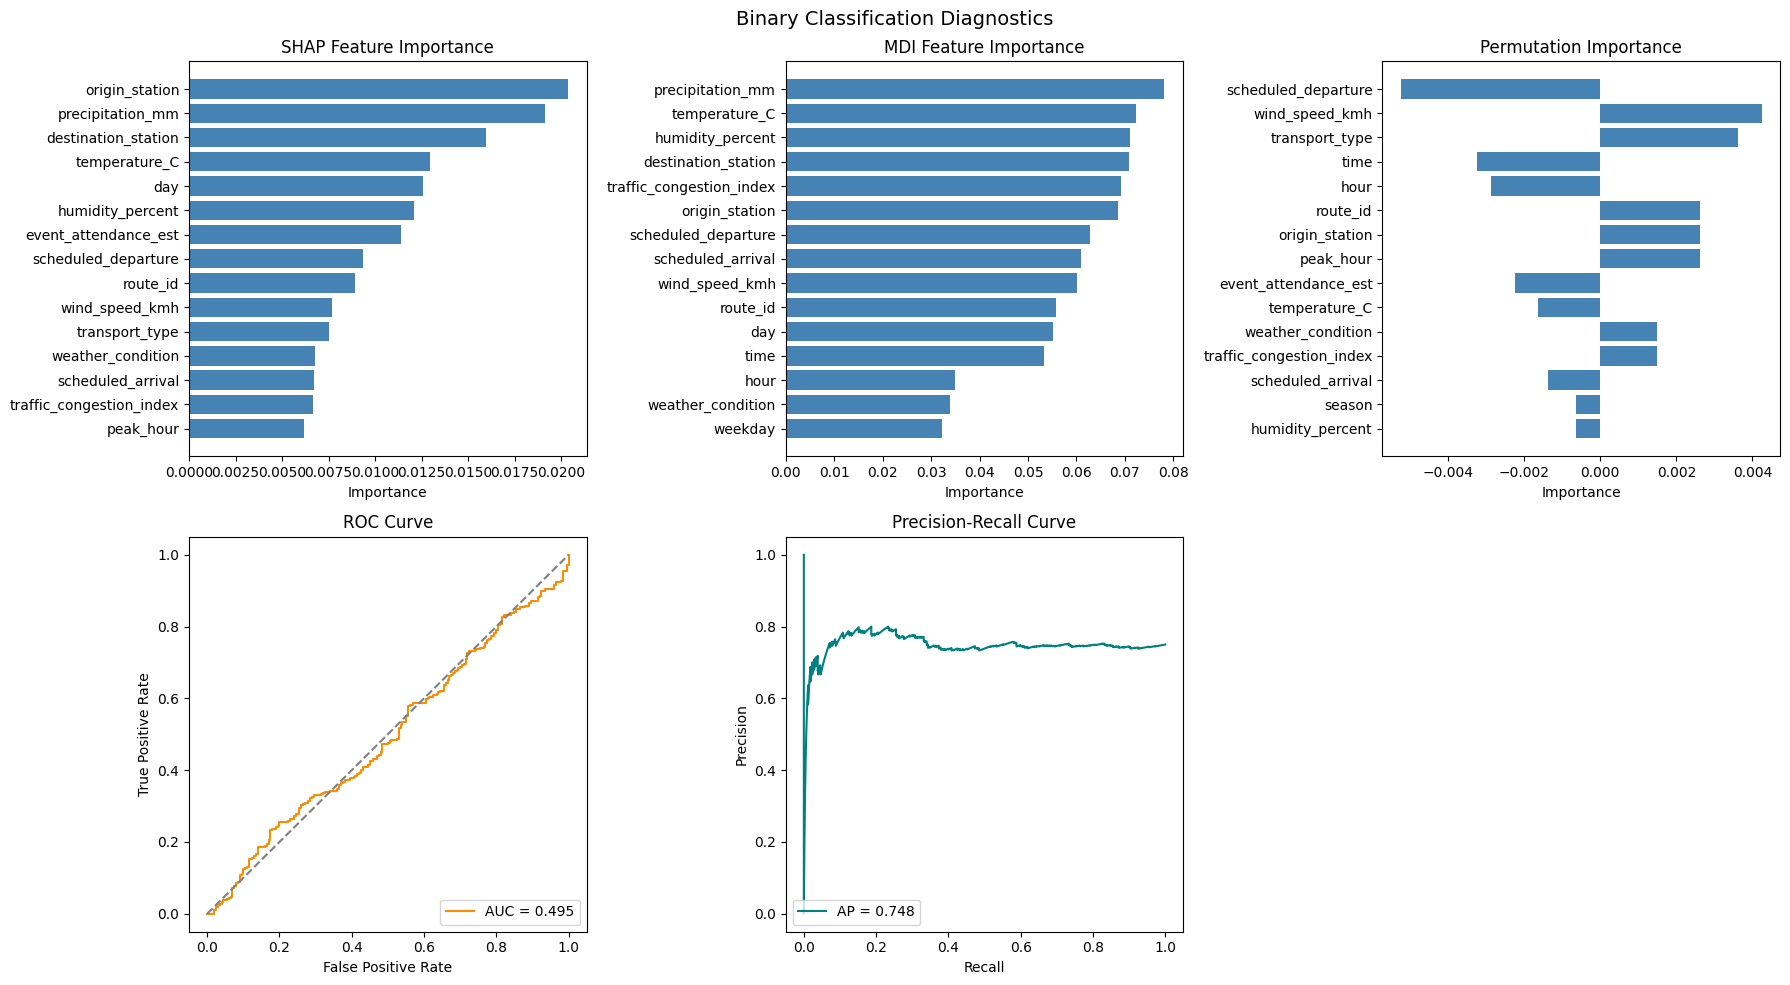

In [72]:
best_class_model.fit(X_train_class,y_train_class)
plot_classification_diagnostics(best_class_model,X_test_class,y_test_class)
plt.show()

# Why the Classification Results Look Like This

## Context

Several models were compared for this task, including RandomForestClassifier and SVC, evaluated across multiple training sizes using cross validation, and then confirmed on a held out test set. The best model selected by cross validation score was RandomForestClassifier with a fixed set of hyperparameters (300 estimators, max depth of 10, sqrt max features) and a training size of 0.8. The confusion matrix counts from this comparison confirm exactly what the earlier plots suggested.

## What the Confusion Matrices Show

Across almost every row in both the cross validation table and the test table, `actual_1_predicted_0` is 0. This means the model essentially never misses a positive case, which explains why recall is exactly 1.0 in every single row without exception. At the same time, `actual_0_predicted_0` is 0 or very small compared to `actual_0_predicted_1`, which means most or all negative cases are being predicted as positive. Specificity values of 0.0 or close to it confirm this directly.

In practical terms, these models are not separating the two classes. They are predicting the positive class for nearly every observation, regardless of the input features.

## Cross Validation Versus Test Behavior

During cross validation, RandomForestClassifier shows some ability to identify negative cases (specificity around 0.38 to 0.43 depending on training size), while SVC shows none at all (specificity of exactly 0.0 in every configuration). However, once evaluated on the test set, RandomForestClassifier loses this ability entirely. Every test row for both models shows specificity of 0.0 and recall of 1.0, meaning the partial discrimination seen during training does not transfer to unseen data. This is a strong sign that the small amount of separation observed in cross validation was noise rather than a real pattern, and the model defaults to predicting the majority class once it faces new data.

## Why Precision and F1 Look Deceptively Good

Precision in the test set is 0.75 in every row, which matches the proportion of positive cases in the dataset rather than any genuine predictive skill. When recall is fixed at 1.0 and specificity is 0.0, precision collapses to the base rate of the positive class by construction. F1 follows the same logic and lands around 0.857 across nearly every model and every training size, including very different algorithms such as RandomForestClassifier and SVC. Two unrelated model families converging to almost identical F1 scores is not a coincidence. It reflects the fact that both are performing the same degenerate behavior of predicting positive for everything, so the metric is measuring the class distribution rather than model quality.

## Connecting This to the Earlier Diagnostic Plots

This evidence lines up directly with the ROC and Precision Recall plots from before. An AUC below 0.5 makes sense once it is confirmed that the model is not ranking positives above negatives at all, since it assigns essentially the same outcome to every observation. The flat Precision Recall curve sitting near 0.7 to 0.75 across all recall values is explained by the same mechanism, since precision stays anchored to the base rate when the model never truly separates the classes. Permutation importance near zero also follows naturally, because shuffling a feature cannot meaningfully change predictions that are already close to constant.

## Practical Takeaway

Selecting a model by F1 or accuracy alone was misleading here, since those metrics stayed artificially high due to class imbalance and a model that always favors the positive class. The confusion matrix counts, together with specificity, are what expose the real problem. Before trusting this pipeline, it is worth checking for class imbalance in the target, verifying that the positive class was not accidentally leaked into the features, and testing a simple baseline that always predicts the majority class. If that baseline achieves similar F1 and precision to RandomForestClassifier and SVC, it confirms that neither model is learning a real decision boundary.

In [ ]:
# Concatenate regression results
regression_df = pd.concat([rf_reg_df, sgd_reg_df, xgb_reg_df]).reset_index(drop=True)

# Sort by CV performance (higher neg RMSE is better)
regression_train = regression_df.sort_values(
    by='neg_root_mean_squared_error_cv_mean',
    ascending=False
)

# Sort by λ-score (higher is better)
regression_test = regression_df.sort_values(
    by='λ0.5-score',
    ascending=True
)

# Best model according to λ-score
best_test_reg = regression_test.index[0]
best_model_reg = regression_test.iloc[0]['model']

# Extract best hyperparameters and configuration
best_params_reg = regression_train.loc[best_test_reg, 'neg_root_mean_squared_error_cv_params']
train_size_reg = regression_train.loc[best_test_reg, 'tr_size']
scale_features_reg = regression_train.loc[best_test_reg, 'scale']

# Display results
display(regression_train.head())
display(regression_test.head())

print('\n=======================================================================\n',
      f'Best regression model: {best_model_reg}\n',
      best_params_reg,
      '\nTraining size:',
      train_size_reg,
      f'\nScale: {scale_features_reg}')
print('\n=======================================================================\n')


In [ ]:
data_reg = preprocess(df,'regression',ensamble=True)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = split_normalize_data(
    data_reg,train_size_reg,task='regression',scale=scale_features_reg)

best_reg_model = RandomForestRegressor(**best_params_reg,random_state=seed)\
                                          .fit(X_train_reg,y_train_reg)

plot_regression_diagnostics(best_reg_model,X_test_reg,y_test_reg)
plt.show()

In [ ]:
# regression with delayed as feature
rf_reg_df_2 = _find_best_model(
    model = rf_reg,
    data = df,
    hy_p_dict = rf_reg_hy,
    task = 'regression',
    ensemble = True,
    RandomSearchCV = True,
    delayed_known=True,
    verbose=1
)

sgd_reg_df_2 = _find_best_model(
    model = sgd_reg,
    data = df,
    hy_p_dict = sgd_reg_hy,
    task = 'regression',
    scaler = True,
    RandomSearchCV = True,
    delayed_known=True,
    verbose=1
)

xgb_reg_df_2 = _find_best_model(
    model = xgb_reg,
    data = df,
    hy_p_dict = xgb_reg_hy,
    task = 'regression',
    ensemble = True,
    RandomSearchCV = True,
    delayed_known=True,
    verbose=1
)

In [ ]:
# Concatenate regression results
regression_df_2 = pd.concat([rf_reg_df_2, sgd_reg_df_2, xgb_reg_df_2]).reset_index(drop=True)

# Sort by CV performance (higher neg RMSE is better)
regression_train_2 = regression_df_2.sort_values(
    by='neg_root_mean_squared_error_cv_mean',
    ascending=False
)

# Sort by λ-score (higher is better)
regression_test_2 = regression_df_2.sort_values(
    by='λ0.5-score',
    ascending=True
)

# Best model according to λ-score
best_test_reg2 = regression_test_2.index[0]
best_model_reg2 = regression_test_2.iloc[0]['model']

# Extract best hyperparameters and configuration
best_params_reg2 = regression_train_2.loc[best_test_reg2, 'neg_root_mean_squared_error_cv_params']
train_size_reg2 = regression_train_2.loc[best_test_reg2, 'tr_size']
scale_features_reg2 = regression_train_2.loc[best_test_reg2, 'scale']

# Display results
display(regression_train_2.head())
display(regression_test_2.head())

print('\n=======================================================================\n',
      f'Best regression model: {best_model_reg2}\n',
      best_params_reg2,
      '\nTraining size:',
      train_size_reg2,
      f'\nScale: {scale_features_reg2}')
print('\n=======================================================================\n')


In [ ]:
data_reg2 = preprocess(df,'regression',ensamble=False,delayed_known=True)
X_train_reg2, X_test_reg2, y_train_reg2, y_test_reg2 = split_normalize_data(
    data_reg2,train_size_reg2,task='regression',scale=scale_features_reg2)

best_reg_model2 = SGDRegressor(**best_params_reg2,random_state=seed)\
                                          .fit(X_train_reg2,y_train_reg2)

plot_regression_diagnostics(best_reg_model2,X_test_reg2,y_test_reg2)
plt.show()

# Why the Diagnostic Plots Look Like This

## Context

Two models were trained on the same regression task. Model A excludes the feature `delayed` (RMSE = 9.3242). Model B includes it (RMSE = 5.8924). The visual patterns in each panel directly reflect how much real signal each model has access to.

## Model A: Without delayed

### Residuals vs Fitted and Actual vs Predicted
Predictions are compressed into a narrow range while residuals cover nearly the full range of the target. The Actual vs Predicted plot is almost flat instead of following the diagonal. This happens when a model cannot separate low and high target values, so it defaults to predicting something close to the average outcome.

### Residual Distribution and Q-Q Plot
Since predictions barely vary, the residuals mirror the shape of the target itself. The Q-Q plot shows light tails compared to a normal distribution, which is consistent with residuals that still contain most of the target's original variance.

## Model B: With delayed

### Residuals vs Fitted and Actual vs Predicted
Predictions now form two distinct clusters instead of one continuous band. Inside each cluster, predictions follow the diagonal reasonably well. This suggests the model is not learning a smooth relationship across the features. It is essentially splitting observations into two groups based on `delayed` and predicting close to the average within each group.

### Interpreting This Pattern
A single binary feature producing this kind of split, combined with a large performance improvement, often points to data leakage. Relevant questions to check include the following. Is `delayed` known at the moment a real prediction would be made, or only after the outcome occurs. Is `delayed` derived from the same event that defines the target.

### Residual Distribution, Q-Q Plot, Scale-Location, Outliers
These panels for Model B still show two separate clusters rather than one unified pattern. This confirms that the improvement in RMSE comes mainly from the split created by `delayed`, not from a richer relationship learned across the full feature set.

## Practical Takeaway

Whether `delayed` represents leakage depends on the data generating process and on what information is genuinely available at prediction time. If `delayed` is only known after the outcome has occurred, it should be removed, and Model A gives a more honest estimate of real world performance.